In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/tmp/ipykernel_58/686013193.py:37: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  returns = prices.pct_change().dropna()


RETURN HARIAN
       BBCA      BBNI      BBRI      ANTM      ASII
1  1.186849  0.019608  0.036145  0.097938  0.000000
2 -0.143827 -0.015385 -0.004651  0.000000 -0.004000
3 -0.204934  0.003906 -0.004673  0.051643 -0.004016
4  0.051478  0.007782  0.016432  0.142857  0.044355
5  1.252787  0.007722  0.020785 -0.011719  0.019305


RETURN EKSPEKTASI
BBCA    0.098598
BBNI    0.000434
BBRI    0.000174
ANTM    0.001168
ASII   -0.000183
dtype: float64


MATRIKS KOVARIANS
          BBCA      BBNI      BBRI      ANTM      ASII
BBCA  0.319294 -0.000208  0.000229 -0.001816  0.001930
BBNI -0.000208  0.000407  0.000031  0.000107  0.000116
BBRI  0.000229  0.000031  0.000486  0.000233  0.000096
ANTM -0.001816  0.000107  0.000233  0.001181  0.000138
ASII  0.001930  0.000116  0.000096  0.000138  0.000279


BOBOT PORTOFOLIO OPTIMAL
  Saham      Proporsi
0  BBCA -2.526210e-17
1  BBNI  2.961433e-01
2  BBRI  2.565915e-01
3  ANTM  2.591422e-02
4  ASII  4.213509e-01


KARAKTERISTIK PORTOFOLIO
Return Portofolio 

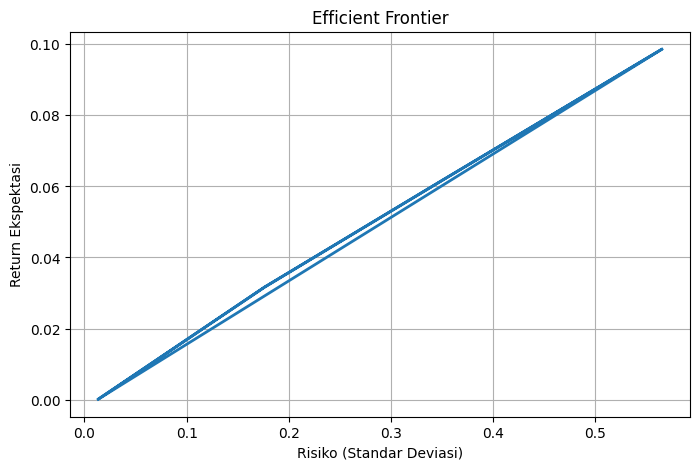

In [7]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

# ==================================================
# MEMBACA DATA
# ==================================================

df = pd.read_excel("/kaggle/input/datasets/faradita29/data-saham-indonesia/Data Saham Indonesia.xlsx")

# ==================================================
# MENGAMBIL KOLOM CLOSE
# ==================================================

# Struktur file:
# BBCA  : kolom 5
# BBNI  : kolom 12
# BBRI  : kolom 19
# ANTM  : kolom 26
# ASII  : kolom 33

prices = pd.DataFrame({
    'BBCA': df.iloc[:, 5],
    'BBNI': df.iloc[:,12],
    'BBRI': df.iloc[:,19],
    'ANTM': df.iloc[:,26],
    'ASII': df.iloc[:,33]
})

prices = prices.dropna()

# ==================================================
# RETURN HARIAN
# ==================================================

returns = prices.pct_change().dropna()

print("="*50)
print("RETURN HARIAN")
print("="*50)
print(returns.head())

# ==================================================
# RETURN EKSPEKTASI
# ==================================================

mu = returns.mean()

print("\n")
print("="*50)
print("RETURN EKSPEKTASI")
print("="*50)
print(mu)

# ==================================================
# MATRIKS KOVARIANS
# ==================================================

Q = returns.cov()

print("\n")
print("="*50)
print("MATRIKS KOVARIANS")
print("="*50)
print(Q)

# ==================================================
# QUADRATIC PROGRAMMING
# MINIMUM VARIANCE PORTFOLIO
# ==================================================

Q_np = Q.values
mu_np = mu.values

n = len(mu_np)

x = cp.Variable(n)

objective = cp.Minimize(
    0.5 * cp.quad_form(x, Q_np)
)

constraints = [
    cp.sum(x) == 1,
    x >= 0
]

problem = cp.Problem(
    objective,
    constraints
)

problem.solve()

weights = x.value

# ==================================================
# BOBOT OPTIMAL
# ==================================================

weights_df = pd.DataFrame({
    'Saham': returns.columns,
    'Proporsi': weights
})

print("\n")
print("="*50)
print("BOBOT PORTOFOLIO OPTIMAL")
print("="*50)
print(weights_df)

# ==================================================
# RETURN PORTOFOLIO
# ==================================================

portfolio_return = np.dot(mu_np, weights)

# ==================================================
# RISIKO PORTOFOLIO
# ==================================================

portfolio_variance = weights.T @ Q_np @ weights

portfolio_std = np.sqrt(portfolio_variance)

print("\n")
print("="*50)
print("KARAKTERISTIK PORTOFOLIO")
print("="*50)

print("Return Portofolio =", portfolio_return)
print("Variansi Portofolio =", portfolio_variance)
print("Standar Deviasi =", portfolio_std)

# ==================================================
# EFFICIENT FRONTIER
# ==================================================



for lam in lambdas:

    w = cp.Variable(n)

    objective = cp.Minimize(
        0.5 * cp.quad_form(w, Q_np)
        - lam * mu_np.T @ w
    )

    constraints = [
        cp.sum(w) == 1,
        w >= 0
    ]

    problem = cp.Problem(
        objective,
        constraints
    )

    problem.solve()

    weight = w.value

    port_return = mu_np @ weight

    port_risk = np.sqrt(
        weight.T @ Q_np @ weight
    )

    return_list.append(port_return)
    risk_list.append(port_risk)

# ==================================================
# GRAFIK EFFICIENT FRONTIER
# ==================================================

plt.figure(figsize=(8,5))

plt.plot(
    risk_list,
    return_list,
    linewidth=2
)

plt.xlabel("Risiko (Standar Deviasi)")
plt.ylabel("Return Ekspektasi")
plt.title("Efficient Frontier")

plt.grid(True)

plt.show()

        Date    High     Low  Open   Close       Volume    Adj Close  \
0 2021-01-04  6855.0  6720.0  6800  6835.0   47937000.0  6717.969727   
1 2021-01-05  7090.0  6850.0  6860  7090.0  104831000.0  6968.603516   
2 2021-01-06  7075.0  6880.0  7050  6945.0   89753500.0  6826.085938   
3 2021-01-07  7050.0  6910.0  7000  6965.0   71360000.0  6845.743652   
4 2021-01-08  7080.0  6975.0  7035  7050.0   75033500.0  6929.288086   

   Unnamed: 7     Date.1  High.1  ...      Volume.3  Adj Close.3  Unnamed: 31  \
0         NaN 2021-01-04  6400.0  ...  1.040753e+09  2174.197998          NaN   
1         NaN 2021-01-05  6500.0  ...  1.139015e+09  2213.909424          NaN   
2         NaN 2021-01-06  6550.0  ...  6.292115e+08  2203.981689          NaN   
3         NaN 2021-01-07  6500.0  ...  1.982112e+09  2581.239746          NaN   
4         NaN 2021-01-08  6500.0  ...  1.052618e+09  2581.239746          NaN   

      Date.4  High.4   Low.4 Open.4  Close.4    Volume.4  Adj Close.4  
0 2021-0

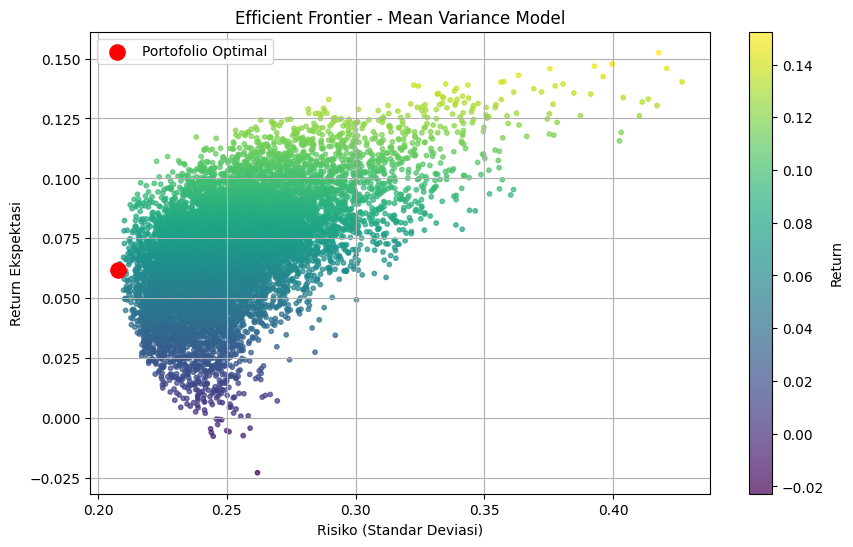

In [10]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

# =====================================================
# MEMBACA DATA
# =====================================================

df = pd.read_excel(
    "/kaggle/input/datasets/faradita29/data-saham-indonesia/Data Saham Indonesia.xlsx"
)

print(df.head())

# =====================================================
# MENGAMBIL KOLOM CLOSE
# =====================================================

prices = pd.DataFrame({
    'BBCA': df['Close'],
    'BBNI': df['Close.1'],
    'BBRI': df['Close.2'],
    'ANTM': df['Close.3'],
    'ASII': df['Close.4']
})

prices = prices.dropna()

# =====================================================
# RETURN HARIAN
# =====================================================

returns = prices.pct_change().dropna()

print("\nRETURN HARIAN")
print(returns.head())

# =====================================================
# RETURN EKSPEKTASI
# =====================================================

mu = returns.mean()

print("\nRETURN EKSPEKTASI")
print(mu)

# =====================================================
# MATRIKS KOVARIANS
# =====================================================

Q = returns.cov()

print("\nMATRIKS KOVARIANS")
print(Q)
Q.to_excel(
    "matriks_kovarians.xlsx"
)
weights_df.to_excel(
    "bobot_portofolio.xlsx",
    index=False
)
# =====================================================
# KONVERSI KE RETURN DAN RISIKO TAHUNAN
# =====================================================

mu_np = mu.values * 252
Q_np = Q.values * 252

# =====================================================
# QUADRATIC PROGRAMMING
# MINIMUM VARIANCE PORTFOLIO
# =====================================================

n = len(mu_np)

x = cp.Variable(n)

objective = cp.Minimize(
    cp.quad_form(x, Q_np)
)

constraints = [
    cp.sum(x) == 1,
    x >= 0
]

problem = cp.Problem(
    objective,
    constraints
)

problem.solve()

weights = x.value

# =====================================================
# BOBOT OPTIMAL
# =====================================================

weights_df = pd.DataFrame({
    'Saham': returns.columns,
    'Proporsi': weights
})

print("\nBOBOT PORTOFOLIO OPTIMAL")
print(weights_df)

# =====================================================
# RETURN PORTOFOLIO
# =====================================================

portfolio_return = np.dot(
    mu_np,
    weights
)

# =====================================================
# RISIKO PORTOFOLIO
# =====================================================

portfolio_variance = (
    weights.T
    @ Q_np
    @ weights
)

portfolio_std = np.sqrt(
    portfolio_variance
)

print("\nRETURN PORTOFOLIO")
print(portfolio_return)

print("\nVARIANSI PORTOFOLIO")
print(portfolio_variance)

print("\nSTANDAR DEVIASI PORTOFOLIO")
print(portfolio_std)

# =====================================================
# SIMULASI MONTE CARLO
# =====================================================
np.random.seed(42)
n_portfolios = 10000

portfolio_returns = []
portfolio_risks = []
portfolio_weights = []

for i in range(n_portfolios):

    w = np.random.random(n)

    w = w / np.sum(w)

    ret = np.dot(
        mu_np,
        w
    )

    risk = np.sqrt(
        w.T
        @ Q_np
        @ w
    )

    portfolio_returns.append(ret)
    portfolio_risks.append(risk)
    portfolio_weights.append(w)

portfolio_returns = np.array(
    portfolio_returns
)

portfolio_risks = np.array(
    portfolio_risks
)

# =====================================================
# GRAFIK EFFICIENT FRONTIER
# =====================================================

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    portfolio_risks,
    portfolio_returns,
    c=portfolio_returns,
    cmap='viridis',
    s=10,
    alpha=0.7
)

plt.scatter(
    portfolio_std,
    portfolio_return,
    color='red',
    s=120,
    label='Portofolio Optimal'
)

plt.xlabel("Risiko (Standar Deviasi)")
plt.ylabel("Return Ekspektasi")
plt.title(
    "Efficient Frontier - Mean Variance Model"
)

plt.legend()

cbar = plt.colorbar(scatter)
cbar.set_label("Return")

plt.grid(True)

plt.show()

In [4]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/faradita29/data-saham-indonesia/Data Saham Indonesia.xlsx
